This program implements the Quantum Haar Wavelet transform on Qiskit. Author: Dhruv Bhatnagar.
Importing standard Qiskit libraries and configuring account

In [21]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.compiler import transpile
from qiskit.quantum_info import Statevector, partial_trace
from qiskit_aer import AerSimulator
from qiskit.visualization import *
from qiskit import QuantumRegister, ClassicalRegister
from wt_functions import *

In [22]:
np.random.seed(0)
amps = np.random.rand(32).astype(float)
norm = np.linalg.norm(amps)
amps = amps / norm

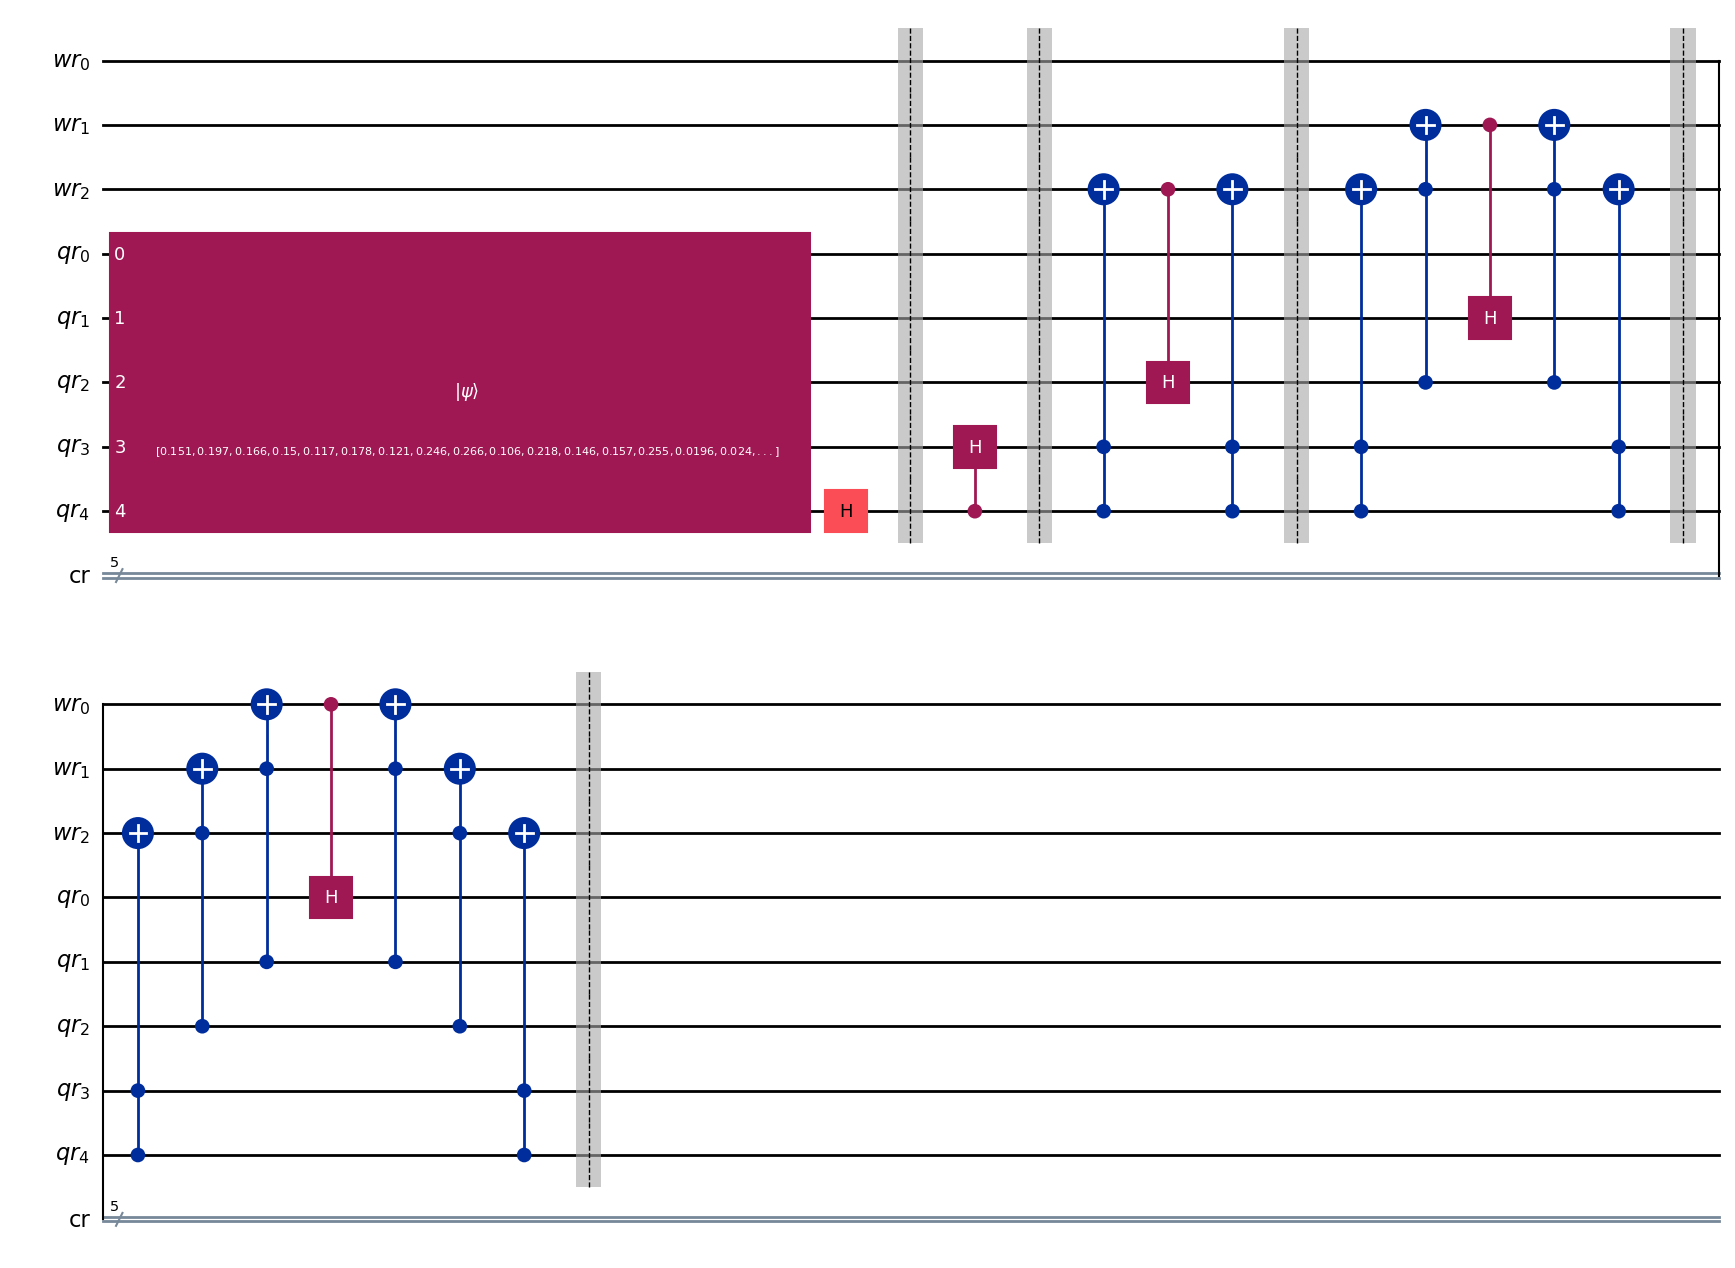

In [23]:
# Build the quantum circuit
# n = 5: number of qubits

q = QuantumRegister(5, name = 'qr')
w = QuantumRegister(3, name = 'wr')
c = ClassicalRegister(5, name = 'cr')

circ = QuantumCircuit(w, q, c)
circ.initialize(amps, q)
circ.h(q[4])
circ.barrier()
circ.ch(q[4],q[3])
circ.barrier()
circ.ccx(q[4],q[3],w[2])
circ.ch(w[2],q[2])
circ.ccx(q[4],q[3],w[2])
circ.barrier()
circ.ccx(q[4],q[3],w[2])
circ.ccx(q[2],w[2],w[1])
circ.ch(w[1],q[1])
circ.ccx(q[2],w[2],w[1])
circ.ccx(q[4],q[3],w[2])
circ.barrier()
circ.ccx(q[4],q[3],w[2])
circ.ccx(q[2],w[2],w[1])
circ.ccx(q[1],w[1],w[0])
circ.ch(w[0],q[0])
circ.ccx(q[1],w[1],w[0])
circ.ccx(q[2],w[2],w[1])
circ.ccx(q[4],q[3],w[2])
circ.barrier()
#at this point, the controlled Hadamard gates have been implemented.

circ.draw(output='mpl')

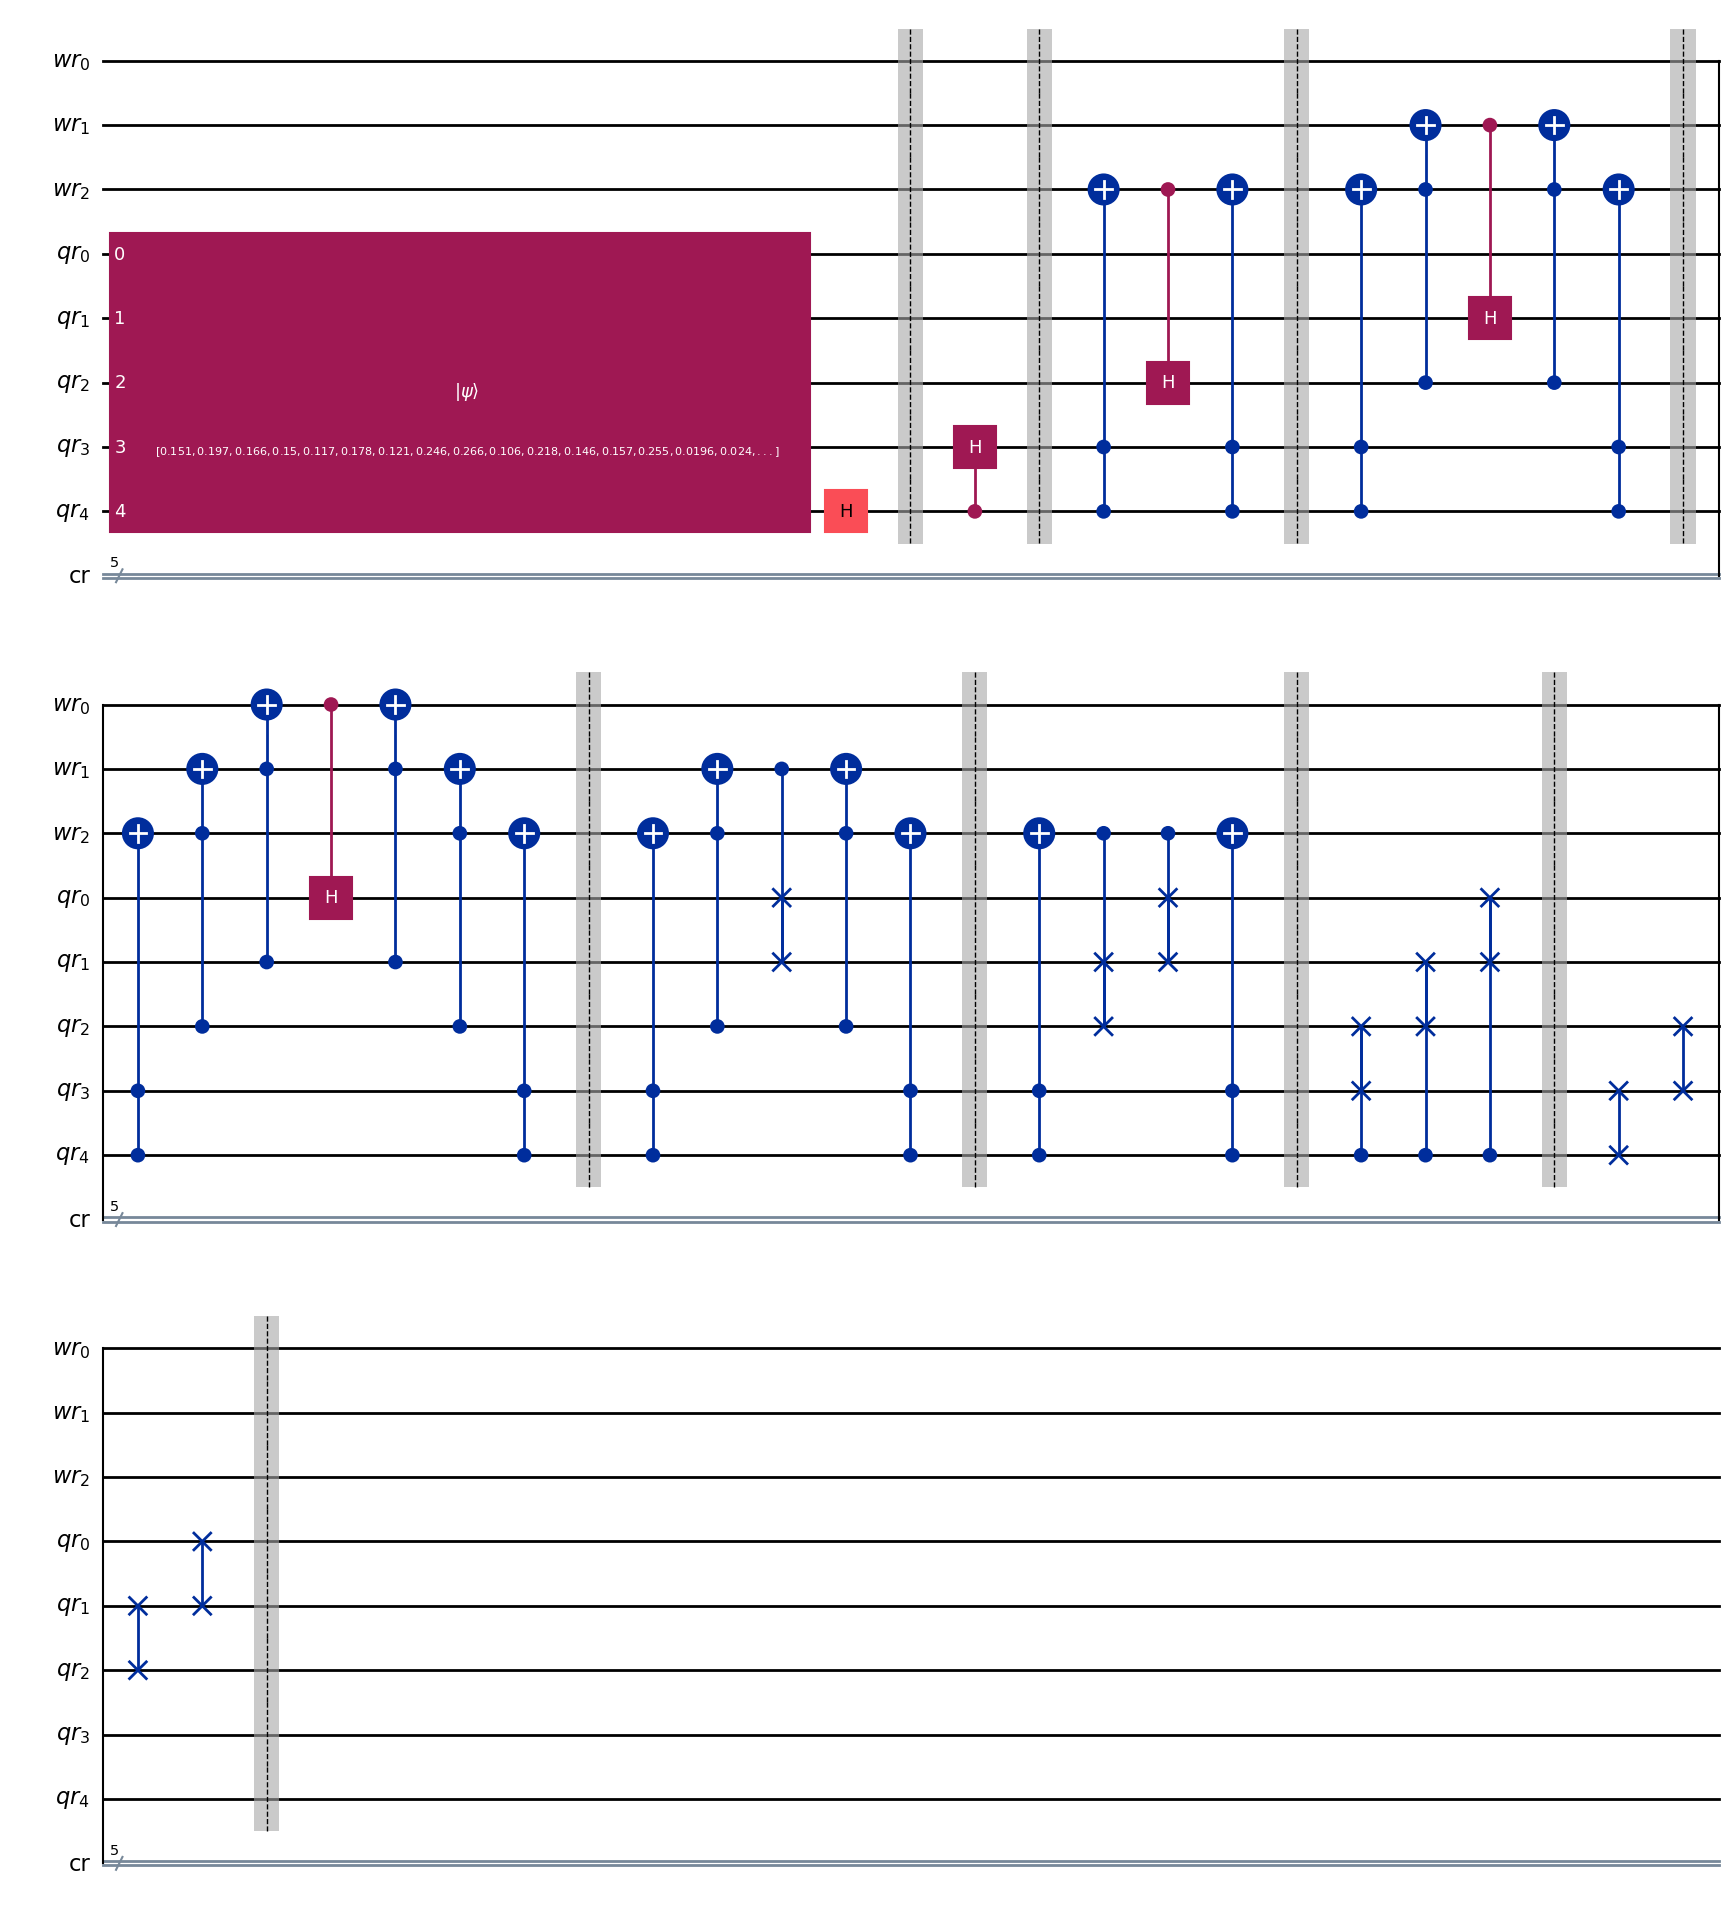

In [24]:
# implementation of pi_4
circ.ccx(q[4],q[3],w[2])
circ.ccx(q[2],w[2],w[1])
circ.cswap(w[1],q[1],q[0])
circ.ccx(q[2],w[2],w[1])
circ.ccx(q[4],q[3],w[2])
circ.barrier()
# implementation of pi_8
circ.ccx(q[4],q[3],w[2])
circ.cswap(w[2],q[2],q[1])
circ.cswap(w[2],q[1],q[0])
circ.ccx(q[4],q[3],w[2])
circ.barrier()
# implementation of pi_16
circ.cswap(q[4],q[3],q[2])
circ.cswap(q[4],q[2],q[1])
circ.cswap(q[4],q[1],q[0])
circ.barrier()
# implementation of pi_32
circ.swap(q[4],q[3])
circ.swap(q[3],q[2])
circ.swap(q[2],q[1])
circ.swap(q[1],q[0])
circ.barrier()

circ.draw(output='mpl')

In [25]:
simulator = AerSimulator(method="statevector")
circ.save_statevector()
compiled_circuit = transpile(circ, simulator)
result = simulator.run(compiled_circuit).result()
statevector = result.get_statevector(compiled_circuit)
reduced = partial_trace(statevector, [0, 1, 2]).to_statevector()

cand1, cand2 = haar_transform_1d_classical(amps)

print("quantum\n", np.array(reduced).real)

print("classical\n", cand1)

quantum
 [ 0.11093535  0.30175244  0.26921665  0.27584027  0.27337952  0.28171958
  0.17527711  0.32602291  0.21092857  0.19950918  0.18229777  0.28727796
  0.21247957  0.2612895   0.06542512  0.16792663  0.18940867 -0.08947955
 -0.05154487 -0.04887092  0.06520181 -0.0511902  -0.1021362   0.13591794
 -0.07013544 -0.06376356  0.04930616  0.00658561 -0.029971    0.08665664
 -0.0793845  -0.01136547]
classical
 [ 0.90031953 -0.01034334  0.03384499  0.11712568  0.00124189  0.09902888
 -0.05056909 -0.01258255  0.01604015 -0.03581594  0.00365096  0.18410026
 -0.10963926  0.07385764 -0.04546783 -0.01409954 -0.03243573  0.01128401
 -0.04332656 -0.08854558  0.11311677  0.05123993 -0.0697064  -0.00313745
 -0.15838135 -0.01790763  0.0349865  -0.06220021 -0.10169737 -0.15622012
  0.02089647 -0.09936406]
